# A — Regression Dashboard

**Audience:** anyone asking *"did this compiler change regress or improve the benchmarks?"*

**Structure (Option C — per-comparison).** Every section under §4 corresponds to one comparison block declared in `runbms.yml` (or supplied via `COMPARISONS_OVERRIDE`). Each block is a self-contained story: instruction-count deltas, wall-time and max-RSS tornado plots per pair, a tradeoff scatter restricted to the block's variants, and ranked top-N regressions/improvements.

When `runbms.yml` declares no `comparisons:` block, the loader falls back to a single default block (`BASELINE` vs every other variant) — the rendered output is then equivalent to a traditional single-baseline view.

Configuration knobs are in the next cell. See [README.md §5.6](./README.md) for the YAML schema.

In [1]:
# Configuration — edit here, or override with BENCH_LOGS_DIR.
import os
from pathlib import Path

LOGS_DIR = Path(os.environ.get("BENCH_LOGS_DIR")
                or "../gc-sweep-logs/<SET-BENCH_LOGS_DIR>")
BASELINE = {"version": "trunk-cfb30145", "flags": "baseline"}
TOP_N    = 10
WARN_PCT = 1.0       # instruction-count verdict thresholds
REGRESS_PCT = 3.0

# When not None, ignore the runbms.yml `comparisons:` block and use this
# Python list instead. Same shape as the YAML schema. Useful for ad-hoc
# exploration without editing YAML or re-running benchmarks.
COMPARISONS_OVERRIDE = None
# Example:
# COMPARISONS_OVERRIDE = [
#     {"label": "flambda only", "a": "ocaml-5.4.1", "b": "ocaml-5.4.1-flambda"},
# ]

CACHE = Path.cwd() / "cache" / "macrobench.parquet"
if not LOGS_DIR.exists():
    raise SystemExit(
        f"LOGS_DIR does not exist: {LOGS_DIR.resolve()}\n"
        "Set BENCH_LOGS_DIR to your run directory, e.g.:\n"
        "  BENCH_LOGS_DIR=../gc-sweep-logs/monolith-2026-05-07-Thu-110013 jupyter ...\n"
        "or edit this cell."
    )
print("LOGS_DIR =", LOGS_DIR.resolve())
print("BASELINE =", BASELINE)
print("COMPARISONS_OVERRIDE =", COMPARISONS_OVERRIDE)

LOGS_DIR = /home/udesou/macro-benches/results/logs/2026-05-26-pr14796-so-sweep-monolith
BASELINE = {'version': 'trunk-cfb30145', 'flags': 'baseline'}
COMPARISONS_OVERRIDE = None


In [2]:
%matplotlib inline
import sys
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from macrobench_loader import (
    load_macro_dataframe, load_comparisons, audit_comparison_coverage,
    instruction_count_deltas,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## 1. Load

Parses every `.log` + `olly_*.json` + `perf_*.json` in `LOGS_DIR` and writes a parquet cache. Subsequent runs read the cache. Delete `cache/macrobench.parquet` to force a rebuild.

In [3]:
if CACHE.exists():
    df = pd.read_parquet(CACHE)
    print(f"Loaded cache: {CACHE}  shape={df.shape}")
else:
    df = load_macro_dataframe(LOGS_DIR)
    CACHE.parent.mkdir(exist_ok=True)
    df.to_parquet(CACHE)
    print(f"Built cache:  {CACHE}  shape={df.shape}")

variants = sorted(df["variant"].unique())
benches  = sorted(df["benchmark"].unique())
print(f"{len(benches)} benchmarks × {len(variants)} variants")
print("variants:", variants)

Built cache:  /tmp/cache/macrobench.parquet  shape=(5875, 50)
24 benchmarks × 2 variants
variants: ['gc-pacing/baseline', 'trunk-cfb30145/baseline']


## 2. Sanity & schema

Three checks before any plotting:

1. **Completeness** — for every (benchmark, variant) cell, how many invocations were recorded?
2. **NaN audit** — which metric columns are partially or fully empty?
3. **Schema sanity** — does every declared runtime have data, and is every loaded variant rendered by some comparison block?

Completeness: 47 / 48 cells populated
Invocations per cell: min=0  max=125

Benchmarks with missing variants:
variant            gc-pacing/baseline  trunk-cfb30145/baseline
benchmark                                                     
pplacer_testsuite                   0                      125


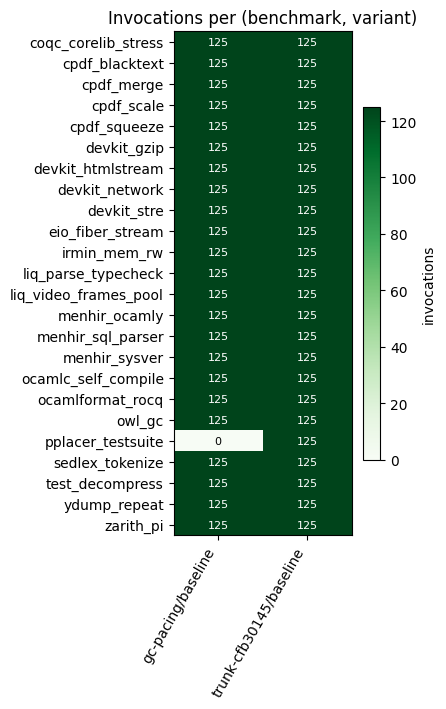

variant,gc-pacing/baseline,trunk-cfb30145/baseline
benchmark,,
coqc_corelib_stress,125,125
cpdf_blacktext,125,125
cpdf_merge,125,125
cpdf_scale,125,125
cpdf_squeeze,125,125
devkit_gzip,125,125
devkit_htmlstream,125,125
devkit_network,125,125
devkit_stre,125,125


In [4]:
completeness = df.pivot_table(
    index="benchmark", columns="variant",
    values="olly_wall_time_s", aggfunc="count",
).fillna(0).astype(int)

print(f"Completeness: {(completeness > 0).sum().sum()} / {completeness.size} cells populated")
print(f"Invocations per cell: min={completeness.values.min()}  max={completeness.values.max()}")
missing = completeness[(completeness == 0).any(axis=1)]
if not missing.empty:
    print("\nBenchmarks with missing variants:")
    print(missing)

fig, ax = plt.subplots(figsize=(1.2 * len(variants) + 2, max(3, 0.3 * len(benches))))
vmax = max(completeness.values.max(), 1)
im = ax.imshow(completeness.values, aspect="auto", cmap="Greens", vmin=0, vmax=vmax)
ax.set_xticks(range(len(completeness.columns)))
ax.set_xticklabels(completeness.columns, rotation=60, ha="right")
ax.set_yticks(range(len(completeness.index)))
ax.set_yticklabels(completeness.index)
for (i, j), v in np.ndenumerate(completeness.values):
    ax.text(j, i, str(v), ha="center", va="center", fontsize=8,
            color="white" if v >= vmax / 2 else "black")
ax.set_title("Invocations per (benchmark, variant)")
fig.colorbar(im, ax=ax, label="invocations", shrink=0.7)
plt.tight_layout()
plt.show()
completeness

In [5]:
# NaN audit
nan_counts = df.isna().sum().sort_values(ascending=False)
nan_counts[nan_counts > 0].head(20)

m                         5875
M                         5875
perf_page-faults_sec      5612
perf_page-faults_k_sec     263
dtype: int64

In [6]:
# Resolve comparisons (from YAML or override) and audit schema coverage.
comparisons = load_comparisons(
    LOGS_DIR, all_variants=variants,
    baseline=BASELINE, override=COMPARISONS_OVERRIDE,
)
audit = audit_comparison_coverage(LOGS_DIR, df, comparisons)

print("Comparisons declared:")
for c in comparisons:
    print(f"  - {c.label!r}  ({len(c.pairs)} pair{'s' if len(c.pairs) != 1 else ''})")

print(
    f"\nVariant coverage: {audit.comparison_variants_total} / "
    f"{audit.data_variants_total} data variants are referenced by a comparison block."
)
if audit.declared_runtimes_no_data:
    print(
        "\nWARNING: runtimes declared in `runbms.yml runtimes:` but no data "
        "present in the dataset:\n  " + ", ".join(audit.declared_runtimes_no_data)
    )
    print("  → Likely declared but not referenced by any `configs:` entry, "
          "or the run failed for these.")
if audit.data_variants_uncovered:
    print(
        "\nWARNING: variants loaded from the dataset but not rendered by any "
        "comparison block:\n  " + ", ".join(audit.data_variants_uncovered)
    )
    print("  → Add a comparison block (or COMPARISONS_OVERRIDE) that mentions them, "
          "or accept the omission.")

Comparisons declared:
  - 'gc-pacing PR vs trunk merge-base'  (1 pair)

Variant coverage: 2 / 2 data variants are referenced by a comparison block.


## 3. Comparisons overview

One row per declared comparison block, summarising regression/improvement counts and worst/best wall-time Δ. Use this to decide which block in §4 to read first.

In [7]:
def _delta_per_bench(df, av, bv, metric):
    """Δ% per benchmark for the median ratio of (b vs a)."""
    a = df[df["variant"] == av].groupby("benchmark")[metric].median()
    b = df[df["variant"] == bv].groupby("benchmark")[metric].median()
    return ((b / a) - 1.0).dropna() * 100.0


overview_rows = []
for cmp in comparisons:
    deltas = []
    for av, bv in cmp.pairs:
        d = _delta_per_bench(df, av, bv, "olly_wall_time_s")
        deltas.extend(d.values)
    deltas = np.array(deltas)
    if deltas.size == 0:
        overview_rows.append({"block": cmp.label, "pairs": len(cmp.pairs),
                              "datapoints": 0, "regressions ≥1%": 0,
                              "improvements ≤−1%": 0, "worst Δ%": np.nan,
                              "best Δ%": np.nan})
        continue
    overview_rows.append({
        "block": cmp.label,
        "pairs": len(cmp.pairs),
        "datapoints": deltas.size,
        "regressions ≥1%":  int((deltas >=  WARN_PCT).sum()),
        "improvements ≤−1%": int((deltas <= -WARN_PCT).sum()),
        "worst Δ%": round(float(deltas.max()), 2),
        "best Δ%":  round(float(deltas.min()), 2),
    })
overview = pd.DataFrame(overview_rows)
overview

,block,pairs,datapoints,regressions ≥1%,improvements ≤−1%,worst Δ%,best Δ%
0,gc-pacing PR vs trunk merge-base,1,23,2,10,3.17,-1.872059e+08


## 4. Per-comparison detail

One subsection per comparison block. The cell below defines small render helpers; the next cell loops them across every block.

In [8]:
def _tornado_grid(cmp, df, metric, metric_label, benches):
    n_pairs = len(cmp.pairs)
    if n_pairs == 0:
        return
    ncols = min(2, n_pairs)
    nrows = (n_pairs + ncols - 1) // ncols
    height = max(3.0, 0.22 * len(benches)) * nrows + 0.5
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, height), squeeze=False)
    for (av, bv), ax in zip(cmp.pairs, axes.flat):
        d = _delta_per_bench(df, av, bv, metric).reindex(benches).dropna().sort_values()
        if d.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{av}  →  {bv}", fontsize=10)
            continue
        colors = ["#2a9d8f" if x < 0 else "#e76f51" for x in d.values]
        ax.barh(d.index, d.values, color=colors)
        ax.axvline(0, color="black", linewidth=0.7)
        ax.set_title(f"{av}  →  {bv}", fontsize=10)
        ax.set_xlabel(f"{metric_label} Δ%", fontsize=8)
        ax.tick_params(axis="y", labelsize=7)
    for ax in axes.flat[n_pairs:]:
        ax.axis("off")
    fig.suptitle(f"{cmp.label} — {metric_label}", y=1.00, fontsize=11)
    plt.tight_layout()
    plt.show()


def _ranked_block_table(cmp, df, metric, metric_label, top_n):
    rows = []
    for av, bv in cmp.pairs:
        d = _delta_per_bench(df, av, bv, metric)
        for bench, v in d.items():
            rows.append({"benchmark": bench, "a": av, "b": bv, f"{metric_label}_Δ%": round(v, 3)})
    if not rows:
        print(f"  ({metric_label}: no resolvable data)")
        return
    summary = pd.DataFrame(rows)
    print(f"\n{metric_label}: top {top_n} regressions")
    print(summary.sort_values(f"{metric_label}_Δ%", ascending=False).head(top_n).to_string(index=False))
    print(f"\n{metric_label}: top {top_n} improvements")
    print(summary.sort_values(f"{metric_label}_Δ%").head(top_n).to_string(index=False))


def _instruction_count_table(cmp, df, top_n, warn_pct, regress_pct):
    if "perf_instructions" not in df.columns or df["perf_instructions"].isna().all():
        print("  (perf_instructions not available — skipping)")
        return
    rows = []
    for av, bv in cmp.pairs:
        d = _delta_per_bench(df, av, bv, "perf_instructions")
        for bench, v in d.items():
            verdict = (
                "improvement" if v <= -regress_pct
                else "regression" if v >=  regress_pct
                else "warn"        if abs(v) >= warn_pct
                else "neutral"
            )
            rows.append({"benchmark": bench, "a": av, "b": bv,
                         "instructions Δ%": round(v, 3), "verdict": verdict})
    if not rows:
        print("  (no data)")
        return
    t = pd.DataFrame(rows).sort_values("instructions Δ%", ascending=False)
    counts = t["verdict"].value_counts().to_dict()
    print(f"  Verdict counts: {counts}")
    print(f"\n  top {top_n} regressions")
    print(t.head(top_n).to_string(index=False))
    print(f"\n  top {top_n} improvements")
    print(t.tail(top_n).iloc[::-1].to_string(index=False))


def _tradeoff_scatter_block(cmp, df):
    if "max_rss_mb" not in df.columns or df["max_rss_mb"].isna().all():
        print("  (max_rss_mb not available — skipping tradeoff scatter)")
        return
    rows = []
    for av, bv in cmp.pairs:
        wall_d = _delta_per_bench(df, av, bv, "olly_wall_time_s")
        rss_d  = _delta_per_bench(df, av, bv, "max_rss_mb")
        common = wall_d.index.intersection(rss_d.index)
        for bench in common:
            rows.append({"benchmark": bench, "pair": f"{av} → {bv}",
                         "wall_ratio": 1.0 + wall_d[bench] / 100.0,
                         "rss_ratio":  1.0 + rss_d[bench]  / 100.0})
    if not rows:
        print("  (tradeoff: no rows)")
        return
    pts = pd.DataFrame(rows)
    pairs_unique = sorted(pts["pair"].unique())
    fig, ax = plt.subplots(figsize=(8, 7))
    palette = plt.colormaps["tab10"].resampled(max(len(pairs_unique), 10))
    for i, p in enumerate(pairs_unique):
        sub = pts[pts["pair"] == p]
        ax.scatter(sub["wall_ratio"], sub["rss_ratio"], color=palette(i), label=p, alpha=0.75, s=35)
    ax.axhline(1.0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(1.0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("wall time ratio  (b / a)")
    ax.set_ylabel("max RSS ratio  (b / a)")
    ax.set_title(f"{cmp.label} — time × memory tradeoff")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()


def render_block(cmp, df, benches, top_n=10, warn_pct=1.0, regress_pct=3.0):
    display(Markdown(f"### {cmp.label}"))
    pair_lines = "\n".join(f"- `{a}`  →  `{b}`" for a, b in cmp.pairs)
    display(Markdown(f"**Pairs ({len(cmp.pairs)}):**\n\n{pair_lines}"))

    display(Markdown("#### Instruction-count Δ%"))
    _instruction_count_table(cmp, df, top_n, warn_pct, regress_pct)

    display(Markdown("#### Wall-time Δ% per pair"))
    _tornado_grid(cmp, df, "olly_wall_time_s", "wall time", benches)

    display(Markdown("#### Max RSS Δ% per pair"))
    _tornado_grid(cmp, df, "max_rss_mb", "max RSS", benches)

    if "olly_p95_latency_ms" in df.columns and df["olly_p95_latency_ms"].notna().any():
        display(Markdown("#### p95 latency Δ% per pair"))
        _tornado_grid(cmp, df, "olly_p95_latency_ms", "p95 latency", benches)
    if "olly_p99_latency_ms" in df.columns and df["olly_p99_latency_ms"].notna().any():
        display(Markdown("#### p99 latency Δ% per pair"))
        _tornado_grid(cmp, df, "olly_p99_latency_ms", "p99 latency", benches)

    display(Markdown("#### Time × memory tradeoff"))
    _tradeoff_scatter_block(cmp, df)

    display(Markdown("#### Ranked tables (within block)"))
    for metric, label in (
        ("olly_wall_time_s", "wall"),
        ("max_rss_mb", "rss"),
        ("olly_gc_overhead_pct", "gc_overhead"),
    ):
        if metric not in df.columns or df[metric].isna().all():
            continue
        _ranked_block_table(cmp, df, metric, label, top_n)
    print()  # spacing

### gc-pacing PR vs trunk merge-base

**Pairs (1):**

- `trunk-cfb30145/baseline`  →  `gc-pacing/baseline`

#### Instruction-count Δ%

  Verdict counts: {'neutral': 12, 'warn': 7, 'regression': 2, 'improvement': 2}

  top 10 regressions
            benchmark                       a                  b  instructions Δ%    verdict
liq_video_frames_pool trunk-cfb30145/baseline gc-pacing/baseline         1760.746 regression
        menhir_ocamly trunk-cfb30145/baseline gc-pacing/baseline            3.289 regression
           cpdf_scale trunk-cfb30145/baseline gc-pacing/baseline            0.349    neutral
         ydump_repeat trunk-cfb30145/baseline gc-pacing/baseline            0.150    neutral
  coqc_corelib_stress trunk-cfb30145/baseline gc-pacing/baseline            0.003    neutral
    devkit_htmlstream trunk-cfb30145/baseline gc-pacing/baseline           -0.009    neutral
       devkit_network trunk-cfb30145/baseline gc-pacing/baseline           -0.091    neutral
         irmin_mem_rw trunk-cfb30145/baseline gc-pacing/baseline           -0.204    neutral
            zarith_pi trunk-cfb30145/baseline gc-pacing/basel

#### Wall-time Δ% per pair

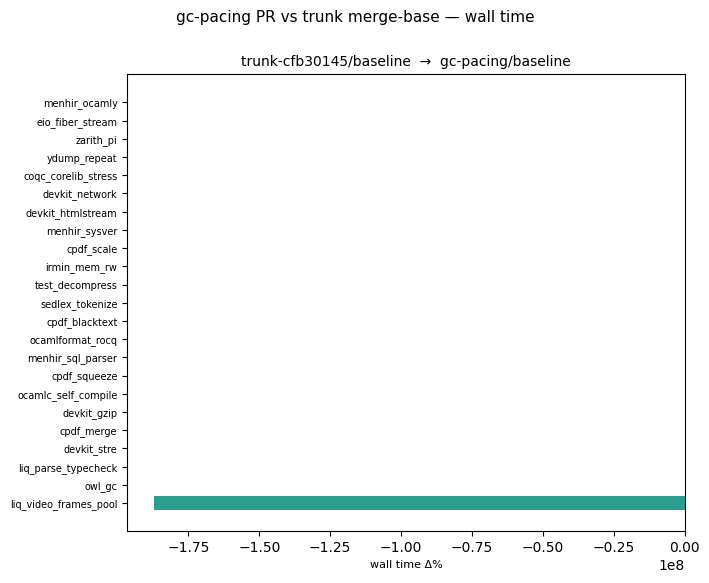

#### Max RSS Δ% per pair

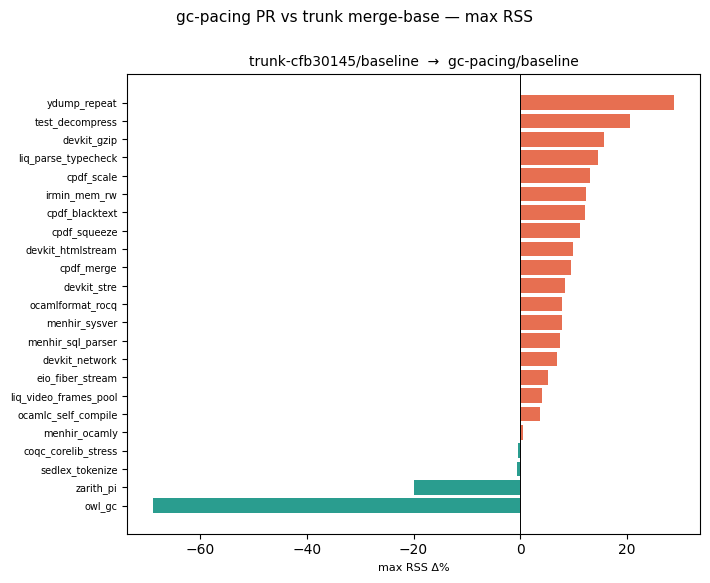

#### p95 latency Δ% per pair

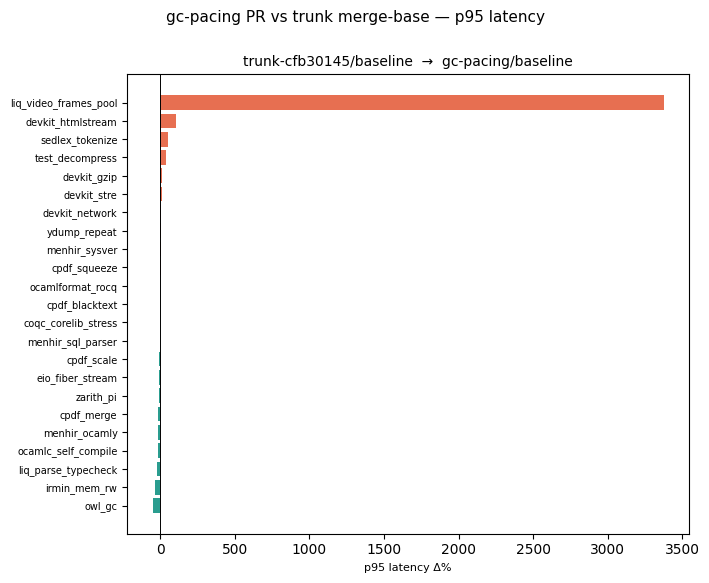

#### p99 latency Δ% per pair

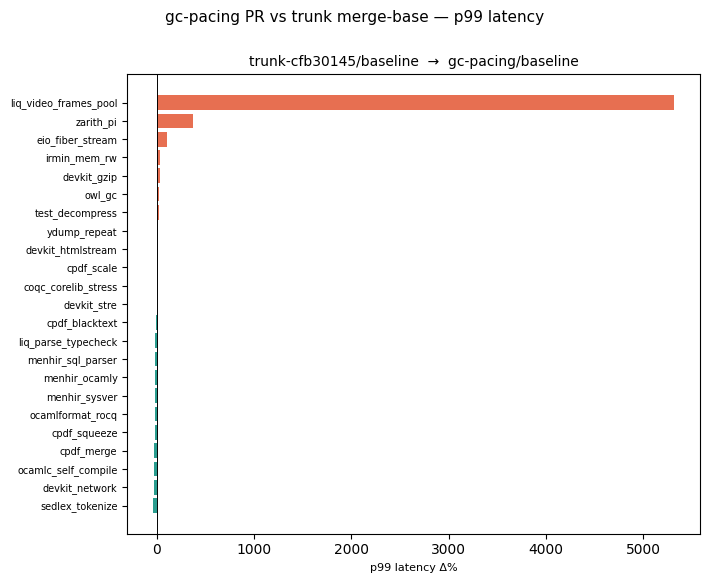

#### Time × memory tradeoff

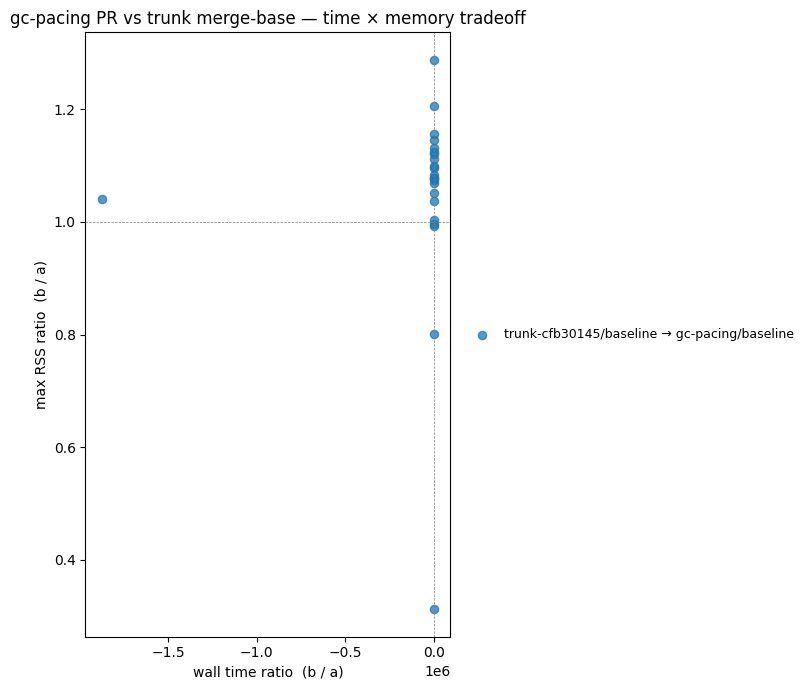

#### Ranked tables (within block)


wall: top 10 regressions
          benchmark                       a                  b  wall_Δ%
      menhir_ocamly trunk-cfb30145/baseline gc-pacing/baseline    3.170
   eio_fiber_stream trunk-cfb30145/baseline gc-pacing/baseline    2.604
          zarith_pi trunk-cfb30145/baseline gc-pacing/baseline    0.926
       ydump_repeat trunk-cfb30145/baseline gc-pacing/baseline    0.830
coqc_corelib_stress trunk-cfb30145/baseline gc-pacing/baseline    0.706
     devkit_network trunk-cfb30145/baseline gc-pacing/baseline    0.598
  devkit_htmlstream trunk-cfb30145/baseline gc-pacing/baseline    0.576
      menhir_sysver trunk-cfb30145/baseline gc-pacing/baseline    0.131
         cpdf_scale trunk-cfb30145/baseline gc-pacing/baseline   -0.079
       irmin_mem_rw trunk-cfb30145/baseline gc-pacing/baseline   -0.536

wall: top 10 improvements
            benchmark                       a                  b       wall_Δ%
liq_video_frames_pool trunk-cfb30145/baseline gc-pacing/baseline -1.872059e+

In [9]:
for cmp in comparisons:
    render_block(cmp, df, benches, top_n=TOP_N,
                 warn_pct=WARN_PCT, regress_pct=REGRESS_PCT)

## 5. CSV export

Long-form: one row per (benchmark, comparison-pair) with the median Δ% for the headline metrics. Writes to `cache/regression_report.csv`.

In [10]:
report_rows = []
metrics_for_report = [
    ("olly_wall_time_s", "wall_Δ%"),
    ("max_rss_mb",       "rss_Δ%"),
    ("olly_gc_overhead_pct", "gc_overhead_Δ%"),
    ("perf_instructions", "instructions_Δ%"),
    ("olly_p95_latency_ms", "p95_latency_Δ%"),
    ("olly_p99_latency_ms", "p99_latency_Δ%"),
]
for cmp in comparisons:
    for av, bv in cmp.pairs:
        per_pair = {
            "comparison": cmp.label,
            "a": av,
            "b": bv,
        }
        per_bench_metric = {}
        for metric, col in metrics_for_report:
            if metric not in df.columns or df[metric].isna().all():
                continue
            d = _delta_per_bench(df, av, bv, metric)
            for bench, v in d.items():
                per_bench_metric.setdefault(bench, {})[col] = round(float(v), 3)
        for bench, mvs in per_bench_metric.items():
            row = {**per_pair, "benchmark": bench}
            row.update(mvs)
            report_rows.append(row)

report = pd.DataFrame(report_rows)
out = Path.cwd() / "cache" / "regression_report.csv"
report.to_csv(out, index=False)
print(f"Wrote {out}  shape={report.shape}")
report.head(10)

Wrote /tmp/cache/regression_report.csv  shape=(23, 10)


,comparison,a,b,benchmark,wall_Δ%,rss_Δ%,gc_overhead_Δ%,instructions_Δ%,p95_latency_Δ%,p99_latency_Δ%
0,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,coqc_corelib_stress,0.706,-0.357,0.123,0.003,-0.302,1.137
1,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,cpdf_blacktext,-0.803,12.076,-5.368,-0.756,0.335,-11.830
2,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,cpdf_merge,-2.347,9.527,-4.664,-2.389,-12.062,-28.458
3,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,cpdf_scale,-0.079,13.118,-4.293,0.349,-6.067,2.746
4,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,cpdf_squeeze,-1.765,11.115,-4.346,-1.751,2.791,-22.589
5,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,devkit_gzip,-2.335,15.655,-39.437,-1.385,14.446,28.959
6,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,devkit_htmlstream,0.576,9.895,-2.101,-0.009,104.856,4.644
7,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,devkit_network,0.598,6.826,-8.144,-0.091,7.330,-33.484
8,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,devkit_stre,-11.804,8.321,-22.442,-0.962,13.589,-2.944
9,gc-pacing PR vs trunk merge-base,trunk-cfb30145/baseline,gc-pacing/baseline,eio_fiber_stream,2.604,5.211,-25.000,-1.010,-8.824,104.768
